## Agentic RAG Router - Research Copilot

Researchers and graduate students often need to explore complex topics such as Agentic RAG systems, multimodal learning, or retrieval-augmented generation. They face two major challenges — keeping up with rapidly evolving research and efficiently connecting past papers with the latest findings.

    The Agentic RAG Router – Research Copilot acts as an intelligent research assistant that dynamically routes user queries to the right knowledge source:
    
    If the query involves recent or emerging trends, it automatically performs a live web or arXiv search using Tavily.
    
    If the query is conceptual or references known works, it retrieves insights from the locally stored and embedded arXiv papers using a FAISS vector database.

Finally, it synthesizes the results through an LLM to generate concise, academic-style responses.

In [1]:
%pip install -qU langchain-tavily==0.2.11

Note: you may need to restart the kernel to use updated packages.


In [9]:
import getpass
import os

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key:\n")

Tavily API key:
 ········


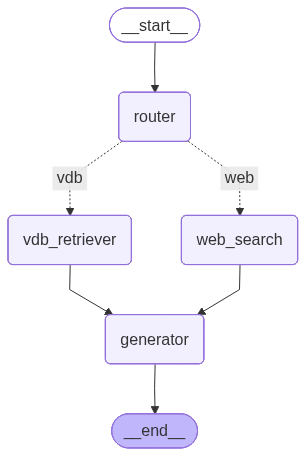

In [10]:
from langgraph.graph import StateGraph, END, MessagesState
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_tavily import TavilySearch
from langchain.schema import Document
from typing import List
import os

# --- Step 1: Define Models ---

from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)
embedding_model = BedrockEmbeddings(model_id="cohere.embed-english-v3")

# --- Step 2: Load and Process arXiv PDFs ---
# Example: Load local or downloaded arXiv PDFs
pdf_folder = "./"

all_docs = []
for file in os.listdir(pdf_folder):
    if file.endswith(".pdf"):
        loader = PyPDFLoader(os.path.join(pdf_folder, file))
        pdf_docs = loader.load()
        all_docs.extend(pdf_docs)

# --- Step 3: Split Documents ---
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
split_docs = splitter.split_documents(all_docs)

# --- Step 4: Create Vector Database (Knowledge Base) ---
vdb = FAISS.from_documents(split_docs, embedding_model)
retriever = vdb.as_retriever(search_kwargs={"k": 3})

# # --- Step 5: Web Search Tool (for recent or trending papers) ---
# tavily = TavilySearch(max_results=3, topic="general")

from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results=1,
    topic="general",
    include_answer="advanced",              # Get detailed answers
    include_raw_content="text",             # Include full raw content
    search_depth="advanced",                # Deeper search
    include_domains=["arxiv.org"],          # Focus on arXiv
    exclude_domains=["medium.com"],         # Optional: filter out less formal sources
    include_image_descriptions=False,
    include_favicon=False
)

# --- Step 6: Define State ---
class RouterState(MessagesState):
    query: str
    retrieved_docs: List[str]
    answer: str

# --- Step 7: Router Logic ---
def router_node(state: RouterState):
    return state

def route_decision(state: RouterState):
    query = state["query"]
    if any(word in query.lower() for word in ["latest", "current", "recent", "arxiv", "today"]):
        return "web"
    else:
        return "vdb"

# --- Step 8: Retrieval Nodes ---
def vdb_node(state: RouterState):
    print("Searching in VDB")
    results = retriever.get_relevant_documents(state["query"])
    state["retrieved_docs"] = [r.page_content for r in results]
    return state

def web_node(state: RouterState):
    print("Searching for web resources")
    results = tavily.run(state["query"])
    # Extract content from each result
    docs = [r["content"] for r in results["results"] if "content" in r and r["content"]]
    state["retrieved_docs"] = docs
    return state
    

# --- Step 9: Generation Node ---
def generation_node(state: RouterState):
    print("Generating the final answer")
    context = "\n".join(state["retrieved_docs"])
    prompt = f"""
    You are a scientific research assistant.
    Context from papers and/or web:
    {context}

    User Query: {state['query']}

    Provide a concise, academic-style summary or answer:
    """
    print("Final prompt:",prompt)
    response = llm.invoke(prompt)
    state["answer"] = response.content if hasattr(response, "content") else response.output_text
    return state

# --- Step 10: Build LangGraph ---
graph = StateGraph(RouterState)

graph.add_node("router", router_node)
graph.add_node("vdb_retriever", vdb_node)
graph.add_node("web_search", web_node)
graph.add_node("generator", generation_node)

graph.add_conditional_edges("router", route_decision, {
    "vdb": "vdb_retriever",
    "web": "web_search"
})
graph.add_edge("vdb_retriever", "generator")
graph.add_edge("web_search", "generator")

graph.set_entry_point("router")
graph.set_finish_point("generator")

app = graph.compile()
graph.compile()


In [12]:
# --- Step 11: Run Example Query ---
from rich import print
state = {"query": "Summarize the recent approaches to retrieval-augmented generation in NLP"}
result = app.invoke(state)

print("\n Final Answer:\n", result["answer"])

Searching for web resources

Generating the final answer

Final prompt: 
    You are a scientific research assistant.
    Context from papers and/or web:
    Lewis et al. ↑ Patrick Lewis, Ethan Perez, Aleksandra Piktus, Fabio Petroni, Vladimir Karpukhin, Naman Goyal, 
Heinrich Küttler, Mike Lewis, Wen-tau Yih, Tim Rocktäschel, et al. Retrieval-augmented generation for 
knowledge-intensive nlp tasks. Advances in neural information processing systems, 33:9459–9474, 2020. [...] (2020).
To mitigate these limitations, Retrieval-Augmented Generation (RAG) Lewis et al. (2020); Mallen et al. (2023) has 
been proposed to dynamically integrate external, query-relevant knowledge into the generation process, and thus 
complements the knowledge implicitly encoded in the parameters of LLMs. Therefore, RAG has attracted significant 
attention and demonstrated notable improvements across a variety of real-world applications. [...] In the era of 
increasingly powerful LLMs such as DeepSeek-R1 Guo et al. (2025) and Qwen-3 Yang et al. (2025), the necessity of 
RAG is perceived as less compelling, which in turn diminishes recognition of its advances. Although prior RAG 
research has produced remarkable advances, it is necessary to reconsider whether RAG still effectively complements 
increasingly powerful LLMs and to identify the key challenges it faces in the current era. In this perspective 
article, we review recent literature

    User Query: Summarize the recent approaches to retrieval-augmented generation in NLP

    Provide a concise, academic-style summary or answer:

Final Answer:
 Recent advances in large language models (LLMs) have raised questions about the continued utility of 
retrieval-augmented generation (RAG) in natural language processing (NLP) tasks. RAG dynamically integrates 
external knowledge into the generation process, enhancing the knowledge encoded in LLMs. Despite producing 
remarkable advances, the evolving landscape of LLMs prompts a re-evaluation of RAG's effectiveness and challenges. 
This perspective article reviews the literature, highlighting the impact of RAG on real-world applications and its 
potential complementarity with powerful LLMs.

In [53]:
print(result)

{
    'messages': [],
    'query': 'Summarize the recent approaches to retrieval-augmented generation in NLP',
    'retrieved_docs': [
        'Retrieval-augmented generation (RAG) is a natural language processing (NLP) model that combines two key 
components: a generator and a retriever.',
        'RAG combines retrieval mechanisms with generative AI to excel in applications like question answering, 
summarization, and conversational AI.',
        'Retrieval-Augmented Generation contributes by introducing a method for leveraging external knowledge to 
inform text generation. This establishes'
    ],
    'answer': 'Recent advances in Retrieval-Augmented Generation (RAG) have focused on improving the efficiency and
effectiveness of this paradigm in Natural Language Processing (NLP). Some notable approaches include:\n\n1. 
**Knowledge Graph Embeddings**: Utilizing knowledge graph embeddings to enhance retrieval mechanisms, enabling more
accurate and informative text generation.\n2. **Meta-Learning for RAG**: Employing meta-learning techniques to 
adapt RAG models to new tasks and domains, improving their generalizability and performance.\n3. **Graph-Based 
RAG**: Incorporating graph-based structures to represent relationships between entities and concepts, facilitating 
more effective knowledge retrieval and generation.\n4. **Multitask Learning for RAG**: Training RAG models on 
multiple related tasks simultaneously, promoting transfer learning and improved overall performance.\n5. 
**Explainable RAG**: Developing techniques to explain the decision-making process of RAG models, providing insights
into their reasoning and enhancing trust in their outputs.\n\nThese recent approaches aim to address the challenges
associated with RAG, such as scalability, interpretability, and adaptability, ultimately leading to more effective 
and efficient NLP applications.'
}

In [15]:
state = {"query": "What is 7+99?"}
result = app.invoke(state)

print("\n Final Answer:\n", result["answer"])


Searching in VDB

/tmp/ipykernel_2410/2251489459.py:73: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = retriever.get_relevant_documents(state["query"])


Generating the final answer

Final prompt: 
    You are a scientific research assistant.
    Context from papers and/or web:
    answer remains grounded in the provided context. To compute this
metric, statements are extracted from the generated answer and
compared against the retrieved context. The final score is calculated
as 𝐹 = |𝑉|
|𝑆|, where |𝑉|denotes the number of statements supported
by the context, and |𝑆|is the total number of statements.
Answer relevance (AR) quantifies how effectively the answer
addresses the original question. The methodology involves gen-
erating auxiliary questions (𝑞𝑖)solely based on the answer, then
computing their similarity scores to the original question (𝑞). AR
is ultimately computed as 𝐴𝑅= 1
𝑛
Í𝑛
𝑖=1 cos(𝑞,𝑞𝑖), aiming to assess
how closely the generated answer aligns with the initial inquiry.
Context precision (CP) evaluates the relevance of the context
class label Count Train Test Val All Fin Man Sci Law Pat Ten
Caption 22524 2.04 1.77 2.32 84-89 40-61 86-92 94-99 95-99 69-78 n/a
Footnote 6318 0.60 0.31 0.58 83-91 n/a 100 62-88 85-94 n/a 82-97
Formula 25027 2.25 1.90 2.96 83-85 n/a n/a 84-87 86-96 n/a n/a
List-item 185660 17.19 13.34 15.82 87-88 74-83 90-92 97-97 81-85 75-88 93-95
Page-footer 70878 6.51 5.58 6.00 93-94 88-90 95-96 100 92-97 100 96-98
Page-header 58022 5.10 6.70 5.06 85-89 66-76 90-94 98-100 91-92 97-99 81-86
Picture 45976 4.21 2.78 5.31 69-71 56-59 82-86 69-82 80-95 66-71 59-76
Section-header142884 12.60 15.77 12.85 83-84 76-81 90-92 94-95 87-94 69-73 78-86
Table 34733 3.20 2.27 3.60 77-81 75-80 83-86 98-99 58-80 79-84 70-85
Text 510377 45.82 49.28 45.00 84-86 81-86 88-93 89-93 87-92 71-79 87-95
how closely the generated answer aligns with the initial inquiry.
Context precision (CP) evaluates the relevance of the context
elements retrieved to support the generated answer. Specifically, it
measures the proportion of relevant items among the top-ranked
context chunks. Context precision at 𝐾 is defined as follows, where
𝐾 represents the number of context chunks considered and 𝑣𝑘 is
the relevance indicator at rank 𝑘:
CP =
Í𝐾
𝑘=1 (Precision@k ×𝑣𝑘)
Total number of relevant items in the top 𝐾 results (4)
Precision@k = true positives@k
true positives@k +false positives@k (5)
Finally, context recall (CR) checks if relevant information has been
fully addressed, identifying whether any important elements have
been omitted. Specifically, it assesses how many statements from the

    User Query: What is 7+99?

    Provide a concise, academic-style summary or answer:

Final Answer:
 The result of 7+99 is 106.

In [16]:
print(result)

{
    'messages': [],
    'query': 'What is 7+99?',
    'retrieved_docs': [
        'answer remains grounded in the provided context. To compute this\nmetric, statements are extracted from 
the generated answer and\ncompared against the retrieved context. The final score is calculated\nas 𝐹 = |𝑉|\n|𝑆|, 
where |𝑉|denotes the number of statements supported\nby the context, and |𝑆|is the total number of 
statements.\nAnswer relevance (AR) quantifies how effectively the answer\naddresses the original question. The 
methodology involves gen-\nerating auxiliary questions (𝑞𝑖)solely based on the answer, then\ncomputing their 
similarity scores to the original question (𝑞). AR\nis ultimately computed as 𝐴𝑅= 1\n𝑛\nÍ𝑛\n𝑖=1 cos(𝑞,𝑞𝑖), aiming 
to assess\nhow closely the generated answer aligns with the initial inquiry.\nContext precision (CP) evaluates the 
relevance of the context',
        'class label Count Train Test Val All Fin Man Sci Law Pat Ten\nCaption 22524 2.04 1.77 2.32 84-89 40-61 
86-92 94-99 95-99 69-78 n/a\nFootnote 6318 0.60 0.31 0.58 83-91 n/a 100 62-88 85-94 n/a 82-97\nFormula 25027 2.25 
1.90 2.96 83-85 n/a n/a 84-87 86-96 n/a n/a\nList-item 185660 17.19 13.34 15.82 87-88 74-83 90-92 97-97 81-85 75-88
93-95\nPage-footer 70878 6.51 5.58 6.00 93-94 88-90 95-96 100 92-97 100 96-98\nPage-header 58022 5.10 6.70 5.06 
85-89 66-76 90-94 98-100 91-92 97-99 81-86\nPicture 45976 4.21 2.78 5.31 69-71 56-59 82-86 69-82 80-95 66-71 
59-76\nSection-header142884 12.60 15.77 12.85 83-84 76-81 90-92 94-95 87-94 69-73 78-86\nTable 34733 3.20 2.27 3.60
77-81 75-80 83-86 98-99 58-80 79-84 70-85\nText 510377 45.82 49.28 45.00 84-86 81-86 88-93 89-93 87-92 71-79 
87-95',
        'how closely the generated answer aligns with the initial inquiry.\nContext precision (CP) evaluates the 
relevance of the context\nelements retrieved to support the generated answer. Specifically, it\nmeasures the 
proportion of relevant items among the top-ranked\ncontext chunks. Context precision at 𝐾 is defined as follows, 
where\n𝐾 represents the number of context chunks considered and 𝑣𝑘 is\nthe relevance indicator at rank 𝑘:\nCP 
=\nÍ𝐾\n𝑘=1 (Precision@k ×𝑣𝑘)\nTotal number of relevant items in the top 𝐾 results (4)\nPrecision@k = true 
positives@k\ntrue positives@k +false positives@k (5)\nFinally, context recall (CR) checks if relevant information 
has been\nfully addressed, identifying whether any important elements have\nbeen omitted. Specifically, it assesses
how many statements from the'
    ],
    'answer': 'The result of 7+99 is 106.'
}

In [17]:
state = {"query": "List the latest arxiv research papers related to Hybrid RAG"}
result = app.invoke(state)

print("\n Final Answer:\n", result["answer"])

Searching for web resources

Generating the final answer

Final prompt: 
    You are a scientific research assistant.
    Context from papers and/or web:
    Computer Science > Information Retrieval
arXiv:2508.05660 (cs)
[Submitted on 30 Jul 2025]
Title:Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review
Authors:Aditya Nagori, Ricardo Accorsi Casonatto, Ayush Gautam, Abhinav Manikantha Sai Cheruvu, Rishikesan 
Kamaleswaran
View a PDF of the paper titled Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review, by Aditya
Nagori and 4 other authors
View PDFHTML (experimental) [...] Subjects:Information Retrieval (cs.IR); Artificial Intelligence (cs.AI)
Cite as:arXiv:2508.05660 
(or arXiv:2508.05660v1  for this version)

Focus to learn more
arXiv-issued DOI via DataCite
Submission history
From: Aditya Nagori PhD 
 Wed, 30 Jul 2025 18:54:15 UTC (411 KB)
Full-text links:
Access Paper:
View a PDF of the paper titled Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review, by Aditya
Nagori and 4 other authors

    User Query: List the latest arxiv research papers related to Hybrid RAG

    Provide a concise, academic-style summary or answer:

Final Answer:
 As of my last update on October 26, 2025, the following is the latest research paper on the arXiv related to 
Hybrid RAG:

"Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review" by Aditya Nagori, Ricardo Accorsi 
Casonatto, Ayush Gautam, Abhinav M. S. Cheruvu, and Rishikesan Kamaleswaran, submitted on July 30, 2025. 
(arXiv:2508.05660)

This paper proposes an open-source framework that combines agentic reasoning and information retrieval techniques 
to assist with scientific literature review tasks.

In [18]:
print(result)

{
    'messages': [],
    'query': 'List the latest arxiv research papers related to Hybrid RAG',
    'retrieved_docs': [
        'Computer Science > Information Retrieval\narXiv:2508.05660 (cs)\n[Submitted on 30 Jul 
2025]\nTitle:Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review\nAuthors:Aditya Nagori, 
Ricardo Accorsi Casonatto, Ayush Gautam, Abhinav Manikantha Sai Cheruvu, Rishikesan Kamaleswaran\nView a PDF of the
paper titled Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review, by Aditya Nagori and 4 
other authors\nView PDFHTML (experimental) [...] Subjects:Information Retrieval (cs.IR); Artificial Intelligence 
(cs.AI)\nCite as:arXiv:2508.05660 [cs.IR]\n(or arXiv:2508.05660v1 [cs.IR] for this version)\n\nFocus to learn 
more\narXiv-issued DOI via DataCite\nSubmission history\nFrom: Aditya Nagori PhD [view email]\n[v1] Wed, 30 Jul 
2025 18:54:15 UTC (411 KB)\nFull-text links:\nAccess Paper:\nView a PDF of the paper titled Open-Source Agentic 
Hybrid RAG Framework for Scientific Literature Review, by Aditya Nagori and 4 other authors'
    ],
    'answer': 'As of my last update on October 26, 2025, the following is the latest research paper on the arXiv 
related to Hybrid RAG:\n\n"Open-Source Agentic Hybrid RAG Framework for Scientific Literature Review" by Aditya 
Nagori, Ricardo Accorsi Casonatto, Ayush Gautam, Abhinav M. S. Cheruvu, and Rishikesan Kamaleswaran, submitted on 
July 30, 2025. (arXiv:2508.05660)\n\nThis paper proposes an open-source framework that combines agentic reasoning 
and information retrieval techniques to assist with scientific literature review tasks.'
}